In [132]:
import pandas as pd
import os

In [133]:
current_dir = os.getcwd()
cache_csv = os.path.join(current_dir, "market_data_cache.csv")

sp500 = pd.read_csv(cache_csv)
sp500.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1,1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
2,1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
3,1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
4,1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0


In [134]:
sp500 = sp500.set_index("Date")
sp500.index

Index(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
       '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
       '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
       '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
       '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
       ...
       '2026-05-11 00:00:00-04:00', '2026-05-12 00:00:00-04:00',
       '2026-05-13 00:00:00-04:00', '2026-05-14 00:00:00-04:00',
       '2026-05-15 00:00:00-04:00', '2026-05-18 00:00:00-04:00',
       '2026-05-19 00:00:00-04:00', '2026-05-20 00:00:00-04:00',
       '2026-05-21 00:00:00-04:00', '2026-05-22 00:00:00-04:00'],
      dtype='object', name='Date', length=24715)

<AxesSubplot:xlabel='Date'>

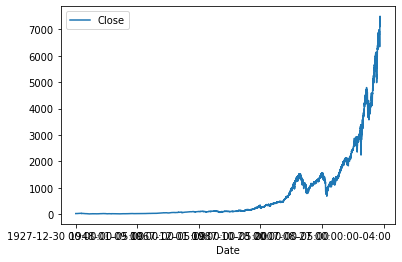

In [135]:
sp500.plot.line(y="Close", use_index=True)

In [136]:
del sp500["Dividends"]
del sp500["Stock Splits"]
sp500.head()

,Open,High,Low,Close,Volume
Date,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0


In [137]:
sp500["Tomorrow"] = sp500["Close"].shift(-1)
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000


In [138]:
sp500["Target"] = (sp500["Tomorrow"] > sp500["Close"]).astype(int)
sp500.head()

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000,1
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999,0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999,0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000,1
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000,0


In [139]:
# remove all data before than:
sp500 = sp500.loc["1990-01-01":].copy()
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0
...,...,...,...,...,...,...,...
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215,1
2026-05-20 00:00:00-04:00,7369.189941,7435.689941,7357.459961,7432.970215,5384150000,7445.720215,1


In [140]:
from sklearn.ensemble import RandomForestClassifier

In [141]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

# Split up data
train = sp500.iloc[:-100]
test = sp500.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=None, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=100,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=1, verbose=0,
                       warm_start=False)

In [142]:
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)

In [143]:
precision_score(test["Target"], preds)

0.5897435897435898

<AxesSubplot:xlabel='Date'>

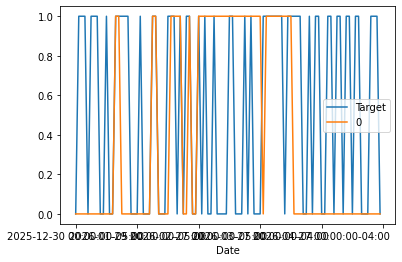

In [144]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [145]:
# Backtesting
def predict(trian, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined
    

In [146]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
        return pd.concat(all_predictions)

In [147]:
predictions = backtest(sp500, model, predictors)

In [148]:
predictions["Predictions"].value_counts()

0    187
1     63
Name: Predictions, dtype: int64

In [149]:
precision_score(predictions["Target"], predictions["Predictions"])

0.9206349206349206

In [150]:
predictions["Target"].value_counts() / predictions.shape[0]

0    0.516
1    0.484
Name: Target, dtype: float64

In [151]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = sp500.rolling(horizon).mean()
    
    ratio_column = f"Close_Ratio_{horizon}"
    sp500[ratio_column] = sp500["Close"] / rolling_averages["Close"]
    
    trend_column = f"Trend_{horizon}"
    sp500[trend_column] = sp500.shift(1).rolling(horizon).sum()["Target"]
    
    new_predictors+= [ratio_column, trend_column]

In [152]:
sp500 = sp500.dropna(subset=sp500.columns[sp500.columns != "Tomorrow"])
sp500

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-18 00:00:00-04:00,7415.069824,7434.060059,7353.169922,7403.049805,5489500000,7353.609863,0,0.999632,0.0,0.996158,2.0,1.069501,32.0,1.112756,140.0,1.410905,541.0
2026-05-19 00:00:00-04:00,7375.750000,7395.319824,7333.680176,7353.609863,5441140000,7432.970215,1,0.996650,0.0,0.990768,2.0,1.061040,32.0,1.104387,140.0,1.400580,540.0
2026-05-20 00:00:00-04:00,7369.189941,7435.689941,7357.459961,7432.970215,5384150000,7445.720215,1,1.005367,1.0,1.001765,2.0,1.071093,32.0,1.115241,141.0,1.414755,541.0


In [153]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [154]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [155]:
predictions = backtest(sp500, model, new_predictors)

In [156]:
predictions["Predictions"].value_counts()

0.0    207
1.0     43
Name: Predictions, dtype: int64

In [157]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5813953488372093

In [158]:
predictions["Target"].value_counts() / predictions.shape[0]

1    0.564
0    0.436
Name: Target, dtype: float64

In [159]:
predictions.tail()

,Target,Predictions
Date,,
2004-11-05 00:00:00-05:00,0,0.0
2004-11-08 00:00:00-05:00,0,0.0
2004-11-09 00:00:00-05:00,0,1.0
2004-11-10 00:00:00-05:00,1,1.0
2004-11-11 00:00:00-05:00,1,0.0
